### Importing Nessasary libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import os
from pathlib import Path
import joblib

print(torch.__version__)

2.14.1+cpu


In [2]:
SEED = 42
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Torch Device : {device}")

Torch Device : cpu


In [3]:
data_path = Path("../dataset/coffee_shop_dataset.csv")
data_url = "https://raw.githubusercontent.com/vijayaideveloper/CoffeeShopRevenuePrediction/refs/heads/main/dataset/coffee_shop_dataset.csv"

In [4]:
df = pd.read_csv(data_path)
df.head()

,Number_of_Customers_Per_Day,Average_Order_Value,Marketing_Spend_Per_Day,Daily_Revenue
0,152,6.74,106.62,1547.81
1,485,4.50,57.83,2084.68
2,398,9.09,91.76,3118.39
3,320,8.48,462.63,2912.20
4,156,7.44,412.52,1663.42


In [5]:
FEATURES = ['Number_of_Customers_Per_Day', 'Average_Order_Value', 'Marketing_Spend_Per_Day']
TARGET = ['Daily_Revenue']

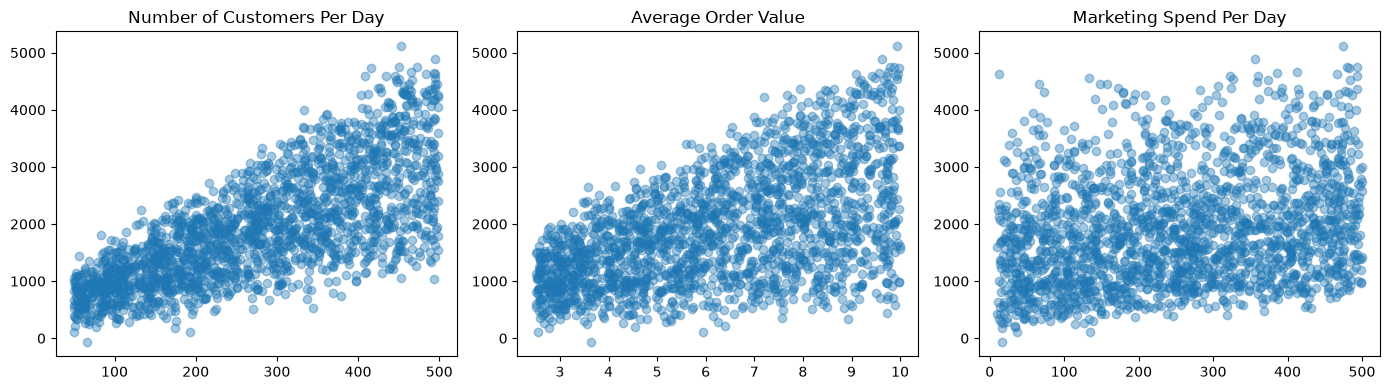

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feature in zip(axes.flatten(), FEATURES):

    ax.scatter(df[feature], df[TARGET], alpha=0.4)
    ax.set_title(feature.replace("_", " "))


plt.tight_layout()
plt.show()

<Axes: >

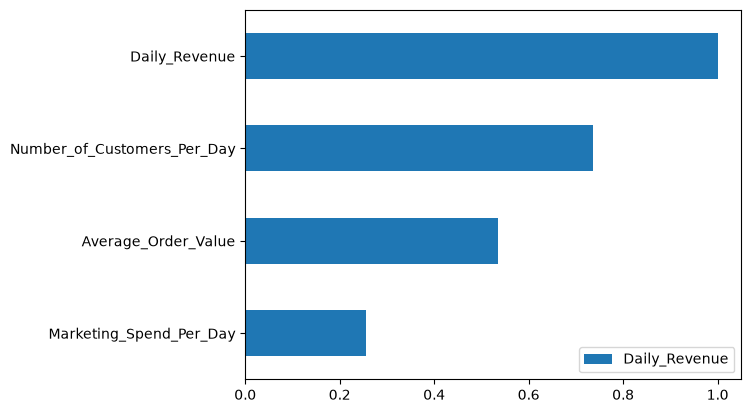

In [21]:
df.corr()[TARGET].sort_values(by=TARGET).plot(kind='barh')

In [26]:
X = df[FEATURES]
y = df[TARGET]

X.shape, y.shape

((2000, 3), (2000, 1))

In [32]:
X_numpy = np.array(X, dtype=np.float32)
y_numpy = np.array(y, dtype=np.float32)

X_numpy.shape, y_numpy.shape

((2000, 3), (2000, 1))

In [33]:
X_numpy.ndim, y_numpy.ndim

(2, 2)

In [34]:
X_numpy[0], y_numpy[0]

(array([152.  ,   6.74, 106.62], dtype=float32),
 array([1547.81], dtype=float32))

In [35]:
SPLIT_SIZE = 0.8
SPLIT_INDEX = int(len(X_numpy) * SPLIT_SIZE)

print(f"Split Size : {SPLIT_SIZE}")
print(f"Split Index : {SPLIT_INDEX}")

X_train, y_train = X_numpy[:SPLIT_INDEX], y_numpy[:SPLIT_INDEX]
X_test, y_test = X_numpy[SPLIT_INDEX:], y_numpy[SPLIT_INDEX:]

(X_train.shape, y_train.shape), (X_test.shape, y_test.shape)

Split Size : 0.8
Split Index : 1600


(((1600, 3), (1600, 1)), ((400, 3), (400, 1)))

In [43]:

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = X_scaler.fit_transform(X_train)
X_test = X_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train)
y_test = y_scaler.transform(y_test)

X_train[0], y_train[0], X_test[0], y_test[0]

(array([-0.9542934 ,  0.22600807, -1.0306313 ], dtype=float32),
 array([-0.38406256], dtype=float32),
 array([-1.5969412 , -1.2387398 , -0.97077966], dtype=float32),
 array([-1.7212998], dtype=float32))

In [44]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

X_train_tensor[0], y_train_tensor[0], X_test_tensor[0], y_test_tensor[0]

(tensor([-0.9543,  0.2260, -1.0306]),
 tensor([-0.3841]),
 tensor([-1.5969, -1.2387, -0.9708]),
 tensor([-1.7213]))

In [45]:
BATCH_SIZE = 32

train_data = TensorDataset(X_train_tensor, y_train_tensor)
test_data = TensorDataset(X_test_tensor, y_test_tensor)

train_dataloader = DataLoader(train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)


len(train_dataloader), len(test_dataloader)

(50, 13)

In [46]:
torch.manual_seed(SEED)

class RevenueBaseModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.layer = nn.Sequential(
            nn.Linear(3, 1)
        )

    def forward(self, x):
        return self.layer(x)

basemodel = RevenueBaseModel().to(device)
basemodel

RevenueBaseModel(
  (layer): Sequential(
    (0): Linear(in_features=3, out_features=1, bias=True)
  )
)

In [47]:
learning_rate = 1e-3

loss_fn = nn.MSELoss()
optimizer = optim.AdamW(params=basemodel.parameters(),
                        lr=learning_rate)

In [63]:
torch.manual_seed(SEED)

TRAIN_LOSS = []
TEST_LOSS = []

TRAIN_ACC = []
TEST_ACC = []

EPOCHS = 50

for epoch in range(EPOCHS):
    basemodel.train()

    train_loss_epoch = 0.0
    train_r2_epoch = 0.0
    train_batches = 0

    for X_batch, y_batch in train_dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        y_pred = basemodel(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        batch_size = X_batch.size(0)
        train_loss_epoch += loss.item() * batch_size
        train_r2_epoch += r2_score(
            y_true=y_batch.detach().cpu().numpy(),
            y_pred=y_pred.detach().cpu().numpy()
        ) * batch_size
        train_batches += batch_size

    basemodel.eval()
    test_loss_epoch = 0.0
    test_r2_epoch = 0.0
    test_batches = 0

    with torch.inference_mode():
        for X_batch, y_batch in test_dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = basemodel(X_batch)
            test_loss = loss_fn(y_pred, y_batch)

            batch_size = X_batch.size(0)
            test_loss_epoch += test_loss.item() * batch_size
            test_r2_epoch += r2_score(
                y_true=y_batch.detach().cpu().numpy(),
                y_pred=y_pred.detach().cpu().numpy()
            ) * batch_size
            test_batches += batch_size

    train_loss_value = train_loss_epoch / train_batches
    train_acc_value = train_r2_epoch / train_batches
    test_loss_value = test_loss_epoch / test_batches
    test_acc_value = test_r2_epoch / test_batches

    TRAIN_LOSS.append(train_loss_value)
    TRAIN_ACC.append(train_acc_value)
    TEST_LOSS.append(test_loss_value)
    TEST_ACC.append(test_acc_value)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1}/{EPOCHS} - "
            f"Train Loss: {train_loss_value:.4f}, Train R²: {train_acc_value:.4f}, "
            f"Test Loss: {test_loss_value:.4f}, Test R²: {test_acc_value:.4f}"
        )


print()
print("Train Loss : ", TRAIN_LOSS[-1])
print("Train Accuracy : ", TRAIN_ACC[-1])
print("Test Loss : ", TEST_LOSS[-1])
print("Test Accuracy : ", TEST_ACC[-1])

Epoch 1/50 - Train Loss: 0.1104, Train R²: 0.8779, Test Loss: 0.1120, Test R²: 0.8939
Epoch 10/50 - Train Loss: 0.1102, Train R²: 0.8793, Test Loss: 0.1120, Test R²: 0.8939
Epoch 20/50 - Train Loss: 0.1103, Train R²: 0.8817, Test Loss: 0.1122, Test R²: 0.8938
Epoch 30/50 - Train Loss: 0.1101, Train R²: 0.8812, Test Loss: 0.1122, Test R²: 0.8938
Epoch 40/50 - Train Loss: 0.1102, Train R²: 0.8810, Test Loss: 0.1121, Test R²: 0.8939
Epoch 50/50 - Train Loss: 0.1101, Train R²: 0.8832, Test Loss: 0.1122, Test R²: 0.8938

Train Loss :  0.11014289289712906
Train Accuracy :  0.8831867623329163
Test Loss :  0.1121526798605919
Test Accuracy :  0.8938446497917175
